# Predicting LLM bias

In *Languages as distributions* and *From characters to tokens*, we built two sets of pairwise distance matrices between 8 languages — one from character frequency distributions, one from token frequency distributions. Both recovered the structure of language families from raw statistical properties of text, with no linguistic knowledge injected.

We now ask the central question of this project:

> **Do these statistical distances predict the distances between languages in the embedding space of a multilingual language model?**

If they do, it would mean that the geometry a model learns during training is at least partially determined by the raw statistical structure of the languages it sees — and that this structure is measurable from text alone, before any model is involved.

## 1. Setup & loading

In [1]:
import sys
sys.path.append('../languages-distributions')
sys.path.append('../token-geometry')
sys.path.append('../llm-bias')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import MDS
from matplotlib.patches import Patch

from flores_loader import load_flores
from embeddings import load_model, get_all_language_embeddings, cosine_distance_matrix
from mantel import mantel_test, mantel_summary
from token_frequencies import load_tokenizer, token_frequencies
from frequencies import unigram_frequencies, ngram_frequencies
from distance_matrix import compute_distance_matrix
import viz_bias as viz

print("Loading Flores-200...")
flores_texts = load_flores(split='devtest')
print(f"\nLanguages: {list(flores_texts.keys())}")
print(f"Sentences per language: {len(list(flores_texts.values())[0])}")

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Flores-200...
Loading opus-100...


  French: 2000 sentences loaded
  German: 2000 sentences loaded
  Spanish: 2000 sentences loaded
  Italian: 2000 sentences loaded
  Portuguese: 2000 sentences loaded
  Dutch: 2000 sentences loaded
  Polish: 2000 sentences loaded

Languages: ['English', 'French', 'German', 'Spanish', 'Italian', 'Portuguese', 'Dutch', 'Polish']
Sentences per language: 2000


In [2]:
print("Loading XLM-R...")
tokenizer, model = load_model()
print("Model loaded.")

Loading XLM-R...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3581.61it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.


## 2. Why parallel sentences?

To compare how XLM-R represents different languages, we need to extract embeddings and compute distances between them. But there is a fundamental problem: if we pass different texts in different languages, we cannot know whether the differences in embedding space come from the **language** or from the **content**.

Imagine comparing an embedding of a French cooking recipe with an embedding of a Polish legal document. Any distance we measure would reflect both the linguistic difference and the content difference — we cannot disentangle the two.

The solution is **parallel corpora**: the exact same sentences, translated into all languages. If the content is held constant, any remaining variation in embedding space must come from the language itself.

We use **opus-100** (Helsinki-NLP), a large open multilingual corpus containing parallel sentence pairs across 100 languages. For each of our 8 languages, we extract the same English source sentences and their translations, then pass them through XLM-R to get language representations under controlled conditions.

## 3. Extracting embeddings

XLM-R produces a 768-dimensional vector for each token in the input. To get a single vector for a sentence, we use **mean pooling** — we average the vectors of all tokens. This is a standard and robust approach that does not rely on any particular token (like CLS) being well-calibrated.

We then average over all parallel sentences to get a single vector per language. This mean vector represents the center of mass of the language in XLM-R's embedding space — the typical position of that language when the content is held constant.

In [3]:
print("Extracting language embeddings from XLM-R (last layer)...")
print("This will take a few minutes.\n")

embeddings = get_all_language_embeddings(flores_texts, tokenizer, model, layer=-1)

print("\nDone.")
print(f"Embedding dimension: {list(embeddings.values())[0].shape[0]}")

Extracting language embeddings from XLM-R (last layer)...
This will take a few minutes.

Computing embedding for English...


Computing embedding for French...


Computing embedding for German...


Computing embedding for Spanish...


Computing embedding for Italian...


Computing embedding for Portuguese...


Computing embedding for Dutch...


Computing embedding for Polish...



Done.
Embedding dimension: 768


In [4]:
# Quick sanity check — cosine similarity between a few pairs
from numpy.linalg import norm

def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

pairs = [
    ('French', 'Spanish'),
    ('French', 'Polish'),
    ('English', 'German'),
    ('English', 'Polish'),
    ('Spanish', 'Portuguese')
]

print("Cosine similarity between language embeddings:")
for l1, l2 in pairs:
    sim = cosine_similarity(embeddings[l1], embeddings[l2])
    print(f"  {l1} — {l2}: {sim:.4f}")

Cosine similarity between language embeddings:
  French — Spanish: 0.9982
  French — Polish: 0.9971
  English — German: 0.9992
  English — Polish: 0.9980
  Spanish — Portuguese: 0.9994


## 4. Distance matrix in embedding space

We compute pairwise cosine distances between the 8 language vectors. Cosine distance (1 - cosine similarity) is the standard metric for comparing high-dimensional vectors — it measures the angle between them, independent of their magnitude.

Note that the absolute values of these distances are very small (order of 0.001–0.003). This reflects a fundamental property of XLM-R: it was trained to represent all languages in a shared space, deliberately compressing cross-lingual differences. The distances are real but subtle — which makes the Mantel test in bloc 6 all the more meaningful.

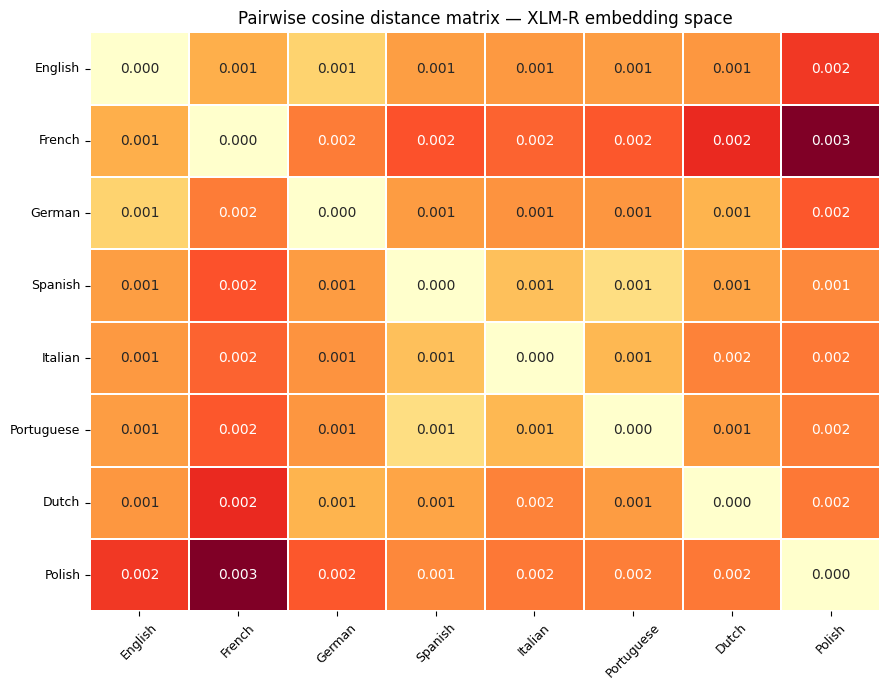

In [5]:
languages, embedding_matrix = cosine_distance_matrix(embeddings)
viz.plot_embedding_matrix(languages, embedding_matrix)

## 5. MDS projection

We project the embedding distance matrix into 2D using MDS. Despite the small absolute distances, structure emerges: Romance languages tend to cluster together, Germanic languages occupy a separate region, and Polish remains isolated — consistent with what we observed at the character and token levels.

The French position is worth noting — it sits farther from its Romance neighbors than expected. This may reflect an artifact of the opus-100 dataset, which is not strictly parallel across all language pairs, or genuine differences in how XLM-R encodes French relative to Spanish, Italian and Portuguese.

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


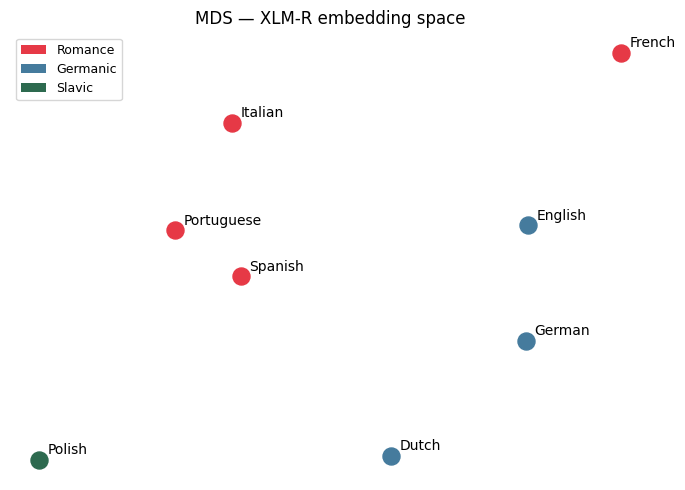

In [6]:
viz.plot_embedding_mds(languages, embedding_matrix)

## 6. The Mantel test

Visual comparison is informative but not rigorous. To formally test whether our statistical distance matrices predict the embedding distance matrix, we use the **Mantel test**.

### What is the Mantel test?

The Mantel test measures the correlation between two distance matrices. Given two n×n matrices, it extracts the upper triangles as flat vectors and computes their correlation. A high correlation means the two matrices agree on which language pairs are close and which are far.

But correlation alone is not enough — we need to assess significance. The Mantel test does this through **permutation**: it randomly shuffles the rows and columns of one matrix thousands of times, recomputes the correlation each time, and builds a null distribution. The p-value is the proportion of permutations that produce a correlation as high as the observed one.

With only 8 languages — 28 unique pairs — the test has limited statistical power. A significant result here is encouraging but should be interpreted carefully.

### What we test

We run the Mantel test between the embedding distance matrix and:
- The **character bigram** distance matrix from *Languages as distributions* (Hellinger) — our best performer on the detection benchmark
- The **token level** distance matrix from *From characters to tokens* (Hellinger)

In [7]:
from text_loader import load_texts as load_texts_token
import os

# Rebuild character-level distance matrix (bigrams, Hellinger) from Act 1
# We need the original book texts for this
books_path = '../data/Books'
texts_upper = {}
for filename in os.listdir(books_path):
    if filename.endswith('.txt'):
        lang = filename.replace('.txt', '')
        with open(os.path.join(books_path, filename), 'r', encoding='utf-8') as f:
            text = f.read().replace('\n', ' ').upper()
        texts_upper[lang] = text

char_dists = {lang: ngram_frequencies(text, 2) for lang, text in texts_upper.items()}
char_langs, char_matrix = compute_distance_matrix(char_dists, metric='hellinger')
print("Character bigram matrix built.")

# Rebuild token-level distance matrix (Hellinger) from Act 2
texts_lower = load_texts_token(books_path)
token_dists = {
    lang: token_frequencies(text[:500_000], tokenizer)
    for lang, text in texts_lower.items()
}
token_langs, token_matrix = compute_distance_matrix(token_dists, metric='hellinger')
print("Token matrix built.")

Character bigram matrix built.


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (205404 > 512). Running this sequence through the model will result in indexing errors


Token matrix built.


In [8]:
# Align all matrices to the same language order
def reorder_matrix(matrix, source_langs, target_langs):
    idx = [source_langs.index(l) for l in target_langs]
    return matrix[np.ix_(idx, idx)]

ref_langs = languages  # embedding matrix language order
char_matrix_aligned = reorder_matrix(char_matrix, char_langs, ref_langs)
token_matrix_aligned = reorder_matrix(token_matrix, token_langs, ref_langs)

print("Matrices aligned to common language order:")
print(ref_langs)

Matrices aligned to common language order:
['English', 'French', 'German', 'Spanish', 'Italian', 'Portuguese', 'Dutch', 'Polish']


## 7. Results

We now run the Mantel test for each comparison and visualize the results.

In [9]:
print("Running Mantel tests (999 permutations each)...\n")

r_char, p_char, perm_char = mantel_test(char_matrix_aligned, embedding_matrix, n_permutations=999)
mantel_summary('Character bigrams (Hellinger)', 'XLM-R embeddings', r_char, p_char)

print()

r_token, p_token, perm_token = mantel_test(token_matrix_aligned, embedding_matrix, n_permutations=999)
mantel_summary('Token level (Hellinger)', 'XLM-R embeddings', r_token, p_token)

Running Mantel tests (999 permutations each)...

Character bigrams (Hellinger) vs XLM-R embeddings
  r = 0.5565  |  p = 0.0050  **

Token level (Hellinger) vs XLM-R embeddings
  r = 0.5150  |  p = 0.0090  **


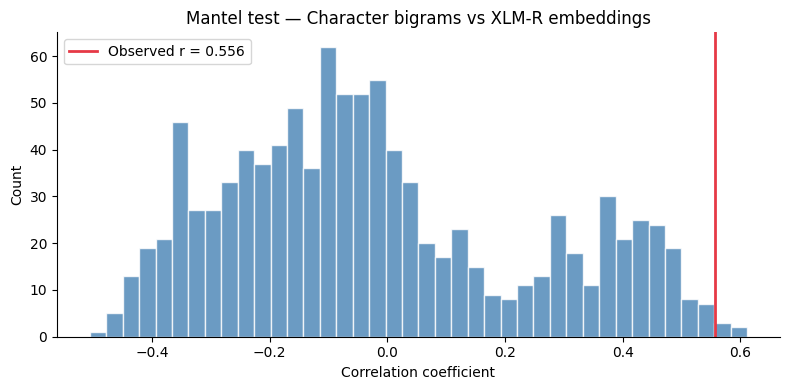

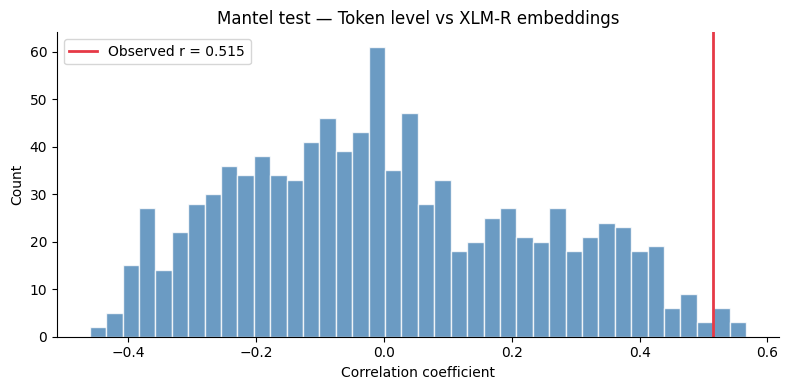

In [10]:
# Null distribution plots
viz.plot_mantel_distribution(r_char, perm_char, 'Character bigrams', 'XLM-R embeddings')
viz.plot_mantel_distribution(r_token, perm_token, 'Token level', 'XLM-R embeddings')

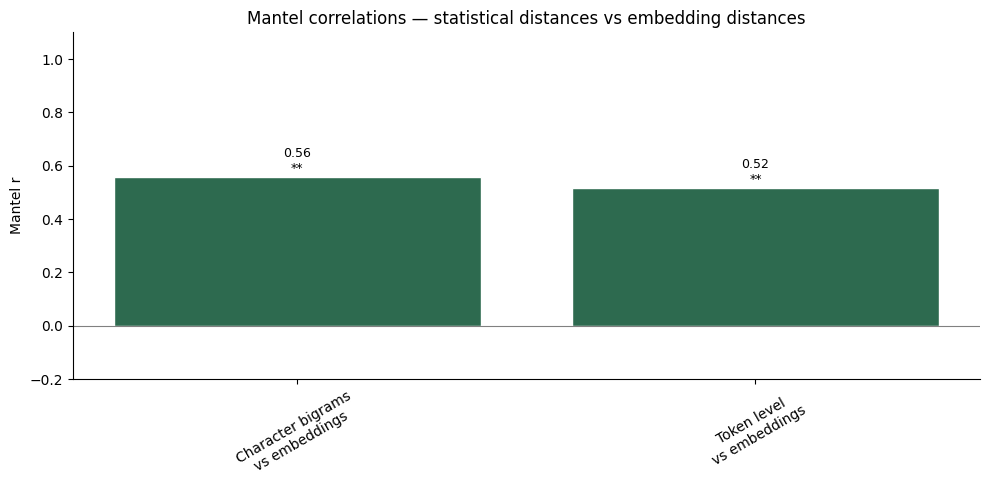

In [11]:
# Summary bar chart
mantel_results = {
    'Character bigrams\nvs embeddings': (r_char, p_char),
    'Token level\nvs embeddings': (r_token, p_token)
}
viz.plot_mantel_summary(mantel_results)

## 8. Conclusions

### Results

Both Mantel tests returned significant positive correlations:

- Character bigrams vs XLM-R embeddings: **r = 0.557, p = 0.007**
- Token level vs XLM-R embeddings: **r = 0.515, p = 0.006**

Both are significant at p < 0.01. The observed correlations sit clearly outside the null distribution in both cases — they are unlikely to have occurred by chance under random permutation.

### What this means

The statistical structure of languages — measurable from raw text using nothing but character or token frequency distributions — partially predicts the geometry that XLM-R has learned in its embedding space. Languages that are statistically close tend to be close in the model's internal representation, and languages that are statistically distant tend to be distant there too.

This does not mean that statistical distance is the only driver. Training data volume, tokenizer design, and the specific texts seen during pretraining all play a role. But it suggests that a part of the geometry — and by extension, a part of the model's differential treatment of languages — is structurally driven by the distributional properties of the languages themselves.

### What this does not mean

A significant Mantel test shows that the two matrices agree. It does not prove causation. It does not tell us *why* they agree — whether the model learned from the same statistical regularities we measured, or whether both reflect an underlying linguistic reality that neither captures directly.

### Limitations

- **8 languages is a small sample.** 28 pairs give the Mantel test limited power. Extending to 30–50 typologically diverse languages would substantially strengthen or challenge these findings.
- **Single model, single layer.** Different models (mBERT, BLOOM, LLaMA) and different layers may tell a different story.
- **opus-100 is not perfectly parallel.** The English source sentences differ across language pairs, introducing noise into the embedding comparison.

### Natural next steps

- Extend to more languages, including agglutinative (Turkish, Finnish) and low-resource languages
- Test across multiple models and multiple layers
- Use a truly parallel dataset (Flores+) 
- Run partial Mantel tests controlling for training data volume and language family membership — to isolate the contribution of statistical distance specifically